# Multivariate logistic Regression 

In [ ]:
You will be looking at the telecom churn prediction example. You will use 21 variables related to customer behaviour (such as the monthly bill, internet usage etc.) to predict whether a particular customer will switch to another telecom provider or not (i.e. churn or not).

 

Problem Statment
You have a telecom firm which has collected data of all its customers. The main types of attributes are:

Demographics (age, gender etc.)
Services availed (internet packs purchased, special offers taken etc.)
Expenses (amount of recharge done per month etc.)
 

Based on all this past information, you want to build a model which will predict whether a particular customer will churn or not, i.e. whether they will switch to a different service provider or not. So the variable of interest, i.e. the target variable here is ‘Churn’ which will tell us whether or not a particular customer has churned. It is a binary variable - 1 means that the customer has churned and 0 means the customer has not churned.

### Read and understand the data's first 

### To read the data - lets import the required libraries 

In [19]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

### Now lets read all the files into our python notebook

In [ ]:
churn_data = pd.read_csv(r"churn_data.csv")
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
customer_data = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIIT-B\Data science\Machine Learning\Module Introduction Logistic Regression\Multivariate Logistic Regression\customer_data.csv")
customer_data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [22]:
internet_data = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIIT-B\Data science\Machine Learning\Module Introduction Logistic Regression\Multivariate Logistic Regression\internet_data.csv")
internet_data.head()

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No


### Merge all the data files into 1 consolidate data frame 

In [23]:
df1 = pd.merge(churn_data, customer_data, how = 'inner', on = 'customerID')

In [24]:
telecom = pd.merge(df1,internet_data, how = 'inner', on ='customerID')

In [25]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Female,...,Yes,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No,Male,...,No,No,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Male,...,No,No,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Male,...,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Female,...,No,No,No,Fiber optic,No,No,No,No,No,No


In [26]:
telecom.shape

(7043, 21)

In [27]:
telecom.describe()

,tenure,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.162147
std,24.559481,30.090047,0.368612
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,0.000000
max,72.000000,118.750000,1.000000


In [28]:
### Lets see what are the types of data we have it in our excel 
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   str    
 3   Contract          7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
 8   Churn             7043 non-null   str    
 9   gender            7043 non-null   str    
 10  SeniorCitizen     7043 non-null   int64  
 11  Partner           7043 non-null   str    
 12  Dependents        7043 non-null   str    
 13  MultipleLines     7043 non-null   str    
 14  InternetService   7043 non-null   str    
 15  OnlineSecurity    7043 non-null   str    
 16  OnlineBackup      7043 non-null   str    
 17  Device

#### so from the above list we can see that we have lot of Object Data type - which is categorical variables 

#### In the above code using telecom.head() . we can see there are lot of columns having the values as Yes and No 
#### lets change or map to 1 or 0 (Yes means 1 and No means 0) - converting them into Numerical values =

In [29]:
# Using the below code we can find the no of values available in the column 
#telecom['PhoneService'].value_counts()
telecom['PaperlessBilling'].value_counts()
telecom['Churn'].value_counts()
telecom['Partner'].value_counts()
telecom['Dependents'].value_counts()
# so using the above code we can see all those column has only 2 values which is YES and NO - so lets pick them and convert that into 1 & 0

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [30]:
### Create a list which has all the categorical values in it 
varlist = ['PhoneService', 'PaperlessBilling', 'Churn', 'Partner', 'Dependents']
def binary_map(x):
    return x.map ({'Yes':1, 'No':0})

In [31]:
telecom[varlist] = telecom[varlist].apply(binary_map)

In [32]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,...,1,0,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,...,0,0,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,...,0,0,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,...,0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,...,0,0,No,Fiber optic,No,No,No,No,No,No


#### Now again lets check the data types available in the dataframe 
#### we can see that few of the data types are changed into integer

In [33]:
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   int64  
 3   Contract          7043 non-null   str    
 4   PaperlessBilling  7043 non-null   int64  
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
 8   Churn             7043 non-null   int64  
 9   gender            7043 non-null   str    
 10  SeniorCitizen     7043 non-null   int64  
 11  Partner           7043 non-null   int64  
 12  Dependents        7043 non-null   int64  
 13  MultipleLines     7043 non-null   str    
 14  InternetService   7043 non-null   str    
 15  OnlineSecurity    7043 non-null   str    
 16  OnlineBackup      7043 non-null   str    
 17  Device

### Create a dummy variables for some of the categoical values and dropping the first variable 

In [34]:
dummy1 = pd.get_dummies(telecom[['Contract', 'PaymentMethod', 'gender', 'InternetService']], drop_first=True )
dummy1 = dummy1.astype(int)

#### Add the above logic into our data frame 

In [35]:
telecom = pd.concat([telecom, dummy1], axis=1)

In [36]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,...,No,No,0,0,0,1,0,0,0,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,...,No,No,1,0,0,0,1,1,0,0
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,...,No,No,0,0,0,0,1,1,0,0
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,...,No,No,1,0,0,0,0,1,0,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,...,No,No,0,0,0,1,0,0,1,0


In [37]:
telecom.shape

(7043, 29)

In [38]:
pd.set_option('display.max_columns', None)
telecom.head

<bound method NDFrame.head of       customerID  tenure  PhoneService        Contract  PaperlessBilling  \
0     7590-VHVEG       1             0  Month-to-month                 1   
1     5575-GNVDE      34             1        One year                 0   
2     3668-QPYBK       2             1  Month-to-month                 1   
3     7795-CFOCW      45             0        One year                 0   
4     9237-HQITU       2             1  Month-to-month                 1   
...          ...     ...           ...             ...               ...   
7038  6840-RESVB      24             1        One year                 1   
7039  2234-XADUH      72             1        One year                 1   
7040  4801-JZAZL      11             0  Month-to-month                 1   
7041  8361-LTMKD       4             1  Month-to-month                 1   
7042  3186-AJIEK      66             1        Two year                 1   

                  PaymentMethod  MonthlyCharges TotalChar

### Creating the dummy variables and for the remaining categorical variables and dropping the level with big names

#### Creating the dummy variables for the column 'Multiplelines' - as this column has more than 2 values list 
#### Yes No NoPhoneService  - Better to keep this with Yes or No values only and drop NoPhoneService value from the list 
### Lets see how to do this in our dataframe 

In [39]:
# Creating dummy variables for the variable 'MultipleLines'
ml = pd.get_dummies(telecom['MultipleLines'], prefix='MultipleLines')
# Dropping MultipleLines_No phone service column
ml1 = ml.drop(['MultipleLines_No phone service'], axis = 1)
ml1=ml1.astype(int)
#Adding the results to the master dataframe
telecom = pd.concat([telecom,ml1], axis=1)

In [40]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,0,0,1,0,0,0,0,0,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,0,0,0,No,DSL,Yes,No,Yes,No,No,No,1,0,0,0,1,1,0,0,1,0
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,0,0,0,No,DSL,Yes,Yes,No,No,No,No,0,0,0,0,1,1,0,0,1,0
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,0,0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,0,0,0,No,Fiber optic,No,No,No,No,No,No,0,0,0,1,0,0,1,0,1,0


#### Now the same what we did for MultipleLines columns - we have to do the same for the other variables also
##### Creating dummy variables for the remaining categorical variables and dropping the level with big names.

In [41]:
### Now lets do the same Creating dummy and updating the dummy variables into our data frame 
os = pd.get_dummies(telecom['OnlineSecurity'], prefix = 'OnlineSecurity')
os1 = os.drop(['OnlineSecurity_No internet service'], axis = 1)
os1=os1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,os1],axis=1)

ob = pd.get_dummies(telecom['OnlineBackup'], prefix = 'OnlineBackup')
ob1 = ob.drop(['OnlineBackup_No internet service'], axis = 1)
ob1=ob1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,ob1],axis=1)

dp = pd.get_dummies(telecom['DeviceProtection'], prefix = 'DeviceProtection')
dp1 = dp.drop(['DeviceProtection_No internet service'], axis = 1)
dp1=dp1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,dp1],axis=1)

ts = pd.get_dummies(telecom['TechSupport'], prefix = 'TechSupport')
ts1 = ts.drop(['TechSupport_No internet service'], axis = 1)
ts1 = ts1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,ts1],axis=1)

st = pd.get_dummies(telecom['StreamingTV'], prefix = 'StreamingTV')
st1 = st.drop(['StreamingTV_No internet service'], axis = 1)
st1 = st1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,st1],axis=1)

sm = pd.get_dummies(telecom['StreamingMovies'], prefix = 'StreamingMovies')
sm1 = sm.drop(['StreamingMovies_No internet service'], axis = 1)
sm1= sm1.astype(int)
### Adding the result to the master data frame
telecom = pd.concat ([telecom,sm1],axis=1)

In [42]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,0,0,0,No,DSL,Yes,No,Yes,No,No,No,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,0,0,0,No,DSL,Yes,Yes,No,No,No,No,0,0,0,0,1,1,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,0,0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,0,0,0,No,Fiber optic,No,No,No,No,No,No,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0


In [43]:
#### So now we have converted all the Categorical Variables into Numberic Variables 
#### As we saw we have segregated the values and updated as a new columns in our dataframe 
#### So lets see the no of columns and the rows available now in our data frame 
telecom.shape

(7043, 43)

##### so earlier it was 21 then when we added Dummies for 4 columns - which mentioned below 
##### 'Contract', 'PaymentMethod', 'gender', 'InternetService' - 4 actual columns and 4 dummies columns in total 8 so 21+8 = 29
##### Then from 21 it went to 29
##### Now when we Segregated the values from the columns which mentioend below 
##### MulitpleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies = total 7 
##### 7 Dummies and 7 Actual values = 7+7 = 14
##### So now 29+14 = 43 - which the count is correct
##### Finally we will remove all the actual columns (Which converted into dummies & values segregated into different columns)

In [44]:
telecom = telecom.drop(['Contract', 'PaymentMethod', 'gender', 'InternetService', 
                        'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                        'StreamingTV', 'StreamingMovies'],axis=1)

In [45]:
##### Now Let check the data frame and the shape of the dataframe 
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0


In [46]:
telecom.shape

(7043, 32)

In [47]:
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7043 non-null   str    
 6   Churn                                  7043 non-null   int64  
 7   SeniorCitizen                          7043 non-null   int64  
 8   Partner                                7043 non-null   int64  
 9   Dependents                             7043 non-null   int64  
 10  Contract_One year                      7043 non-null   int64  
 11  Contract_Two ye

##### So from the above data we can see the data types 
##### Where all the data Types are converted into integer data type, but we can see the Total Charges columns has Object data type
##### Charges will always be in number - which is numerical variable  - but here we have it in categorical vairable (String)
##### So we need to change that into Numerical value 

In [48]:
telecom['TotalCharges'] = telecom['TotalCharges'].str.strip()
telecom['TotalCharges'] = telecom['TotalCharges'].replace('','')

In [49]:
#telecom['TotalCharges'] = pd.to_numeric=True
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

#telecom['TotalCharges'] = telecom['TotalCharges'].astype(float)
#telecom['TotalCharges'] = telecom['TotalCharges'].convert_objects(convert_numeric=True)

In [50]:
telecom.TotalCharges

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [51]:
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7043 non-null   int64  
 7   SeniorCitizen                          7043 non-null   int64  
 8   Partner                                7043 non-null   int64  
 9   Dependents                             7043 non-null   int64  
 10  Contract_One year                      7043 non-null   int64  
 11  Contract_Two ye

In [52]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.50,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0


# Taking a Review here with the below point 

So the process of dummy variable creation was quite familiar, except this time, you manually dropped one of the columns for many dummy variables. 
For example, for the column ‘MultipleLines’, you dropped the level ‘MultipleLines_No phone service’ 
manually instead of simply using ‘drop_first = True’ which would’ve dropped the first level present in the ‘MultipleLines’ column. 
The reason we did this is that if you check the variables ‘MultipleLines’ using the following command, 
you can see that it has the following three levels:
#### telecom["MultipleLines"].astype('category').value_counts() 

## Checking  the outliers 
### checking the outliers on the continous variables 

In [53]:
num_telecom  = telecom[['tenure', 'MonthlyCharges', 'SeniorCitizen', 'TotalCharges']]

In [54]:
### Checking the outliers at 25%, 50%, 75%, 90%, 95% and 99%
num_telecom.describe(percentiles = [.25, .5, .75, .9, .95, .99])

,tenure,MonthlyCharges,SeniorCitizen,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,0.162147,2283.300441
std,24.559481,30.090047,0.368612,2266.771362
min,0.000000,18.250000,0.000000,18.800000
25%,9.000000,35.500000,0.000000,401.450000
50%,29.000000,70.350000,0.000000,1397.475000
75%,55.000000,89.850000,0.000000,3794.737500
90%,69.000000,102.600000,1.000000,5976.640000
95%,72.000000,107.400000,1.000000,6923.590000
99%,72.000000,114.729000,1.000000,8039.883000


In [55]:
### now lets check for the missing values in our DF 
telecom.isnull().sum()

customerID                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
Contract_One year                         0
Contract_Two year                         0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
gender_Male                               0
InternetService_Fiber optic               0
InternetService_No                        0
MultipleLines_No                          0
MultipleLines_Yes                         0
OnlineSecurity_No                         0
OnlineSecurity_Yes                        0
OnlineBackup_No                 

In [56]:
#### We can see there are some missing in values in the column Total Charges - since it is very low number we can delete it
#### how will we find the percentage of the missing values in the dataframe 
tc=round(100*telecom['TotalCharges'].isnull().sum()/len((telecom.index)),2)
tc

np.float64(0.16)

In [57]:
#### aso we can the column TotalCharges has only 0.1 % of effect in the data frame - 
#### So it will not affect more in our dataframe - its better to remove the missing values there in the dataframe 
telecom = telecom[~np.isnan(telecom['TotalCharges'])]

In [58]:
tc=round(100*telecom['TotalCharges'].isnull().sum()/len((telecom.index)),2)
tc

np.float64(0.0)

In [59]:
telecom.isnull().sum()

customerID                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
gender_Male                              0
InternetService_Fiber optic              0
InternetService_No                       0
MultipleLines_No                         0
MultipleLines_Yes                        0
OnlineSecurity_No                        0
OnlineSecurity_Yes                       0
OnlineBackup_No                          0
OnlineBacku

### Yes, now we have the data set ready - by this we have done the data cleaning activities 
### now the DF is ready for us to do the analysis 

## Step 4 - Train & Test split

In [60]:
from sklearn.model_selection import train_test_split 

In [61]:
### Putting Featured variables to X
X = telecom.drop(['Churn', 'customerID'],axis=1)
#### Kinding of removing the Target variables Churn and CustomerID from the data set and splitting it 
#### from the data fram we have removed the churn which is removed from the x axis and moved that to y axis 
#### You can see the y axis code below 
### We have taken the Customerid since this will not help us on our analysis 

In [62]:
### Putting Response variables to y
y = telecom['Churn']

In [63]:
### now lets check how the X and y looks
X.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,1,0,1,29.85,29.85,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0
1,34,1,0,56.95,1889.50,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0
2,2,1,1,53.85,108.15,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0
3,45,0,0,42.30,1840.75,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,1,1,0,1,0
4,2,1,1,70.70,151.65,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0


In [64]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [65]:
X.shape

(7032, 30)

In [66]:
y.shape

(7032,)

In [67]:
### Split these datas into train and test set 
X_train, X_test, y_train,y_test = train_test_split(X, y , train_size=0.7, test_size=0.3, random_state=100)

In [68]:
X_train.shape

(4922, 30)

In [69]:
X_test.shape

(2110, 30)

In [70]:
4922+2110

7032

In [71]:
y_train.shape , y_test.shape

((4922,), (2110,))

## Step 5 - Feature Scaling

In [72]:
from sklearn.preprocessing import StandardScaler

# Scaler formula x-mean/Zigma
scaler = StandardScaler()
#### We are going to do this Scaling process on our Train set 

In [73]:
scaler = StandardScaler()

X_train[['tenure','MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X_train[['tenure','MonthlyCharges', 'TotalCharges']])

X_train.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
879,0.019693,1,1,-0.338074,-0.276449,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,1,0,1,0,1,0,1,0
5790,0.305384,0,1,-0.464443,-0.112702,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,0,1,0,1
6498,-1.286319,1,1,0.581425,-0.974430,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,1,1,0,1,0,1,0
880,-0.919003,1,1,1.505913,-0.550676,0,0,0,0,0,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1
2784,-1.163880,1,1,1.106854,-0.835971,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0,1


#### Scaling of the actual numeric feature is also done using the above code

### Now let check the Churn Rate 

In [74]:
#churn =(sum(telecom['Churn'] ) / len(telecom['Churn']*100))
churn =(sum(telecom['Churn'] ) / len(telecom['Churn'].index))*100
churn

26.578498293515356

# Building your First Model Using Logistic Regression 

### 1st step is to find the correlations between all the variables to see the multicollinearity 

### so here we will use the heatmap to see the best correlations 
### to user heatmap - we need to import Seaborn library as mentioned below

In [75]:
telecom.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   str    
 1   tenure                                 7032 non-null   int64  
 2   PhoneService                           7032 non-null   int64  
 3   PaperlessBilling                       7032 non-null   int64  
 4   MonthlyCharges                         7032 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7032 non-null   int64  
 7   SeniorCitizen                          7032 non-null   int64  
 8   Partner                                7032 non-null   int64  
 9   Dependents                             7032 non-null   int64  
 10  Contract_One year                      7032 non-null   int64  
 11  Contract_Two year   

In [76]:
#telecom=telecom(~np'customerID')
telecom = telecom.drop(['customerID'],axis=1)

In [77]:
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


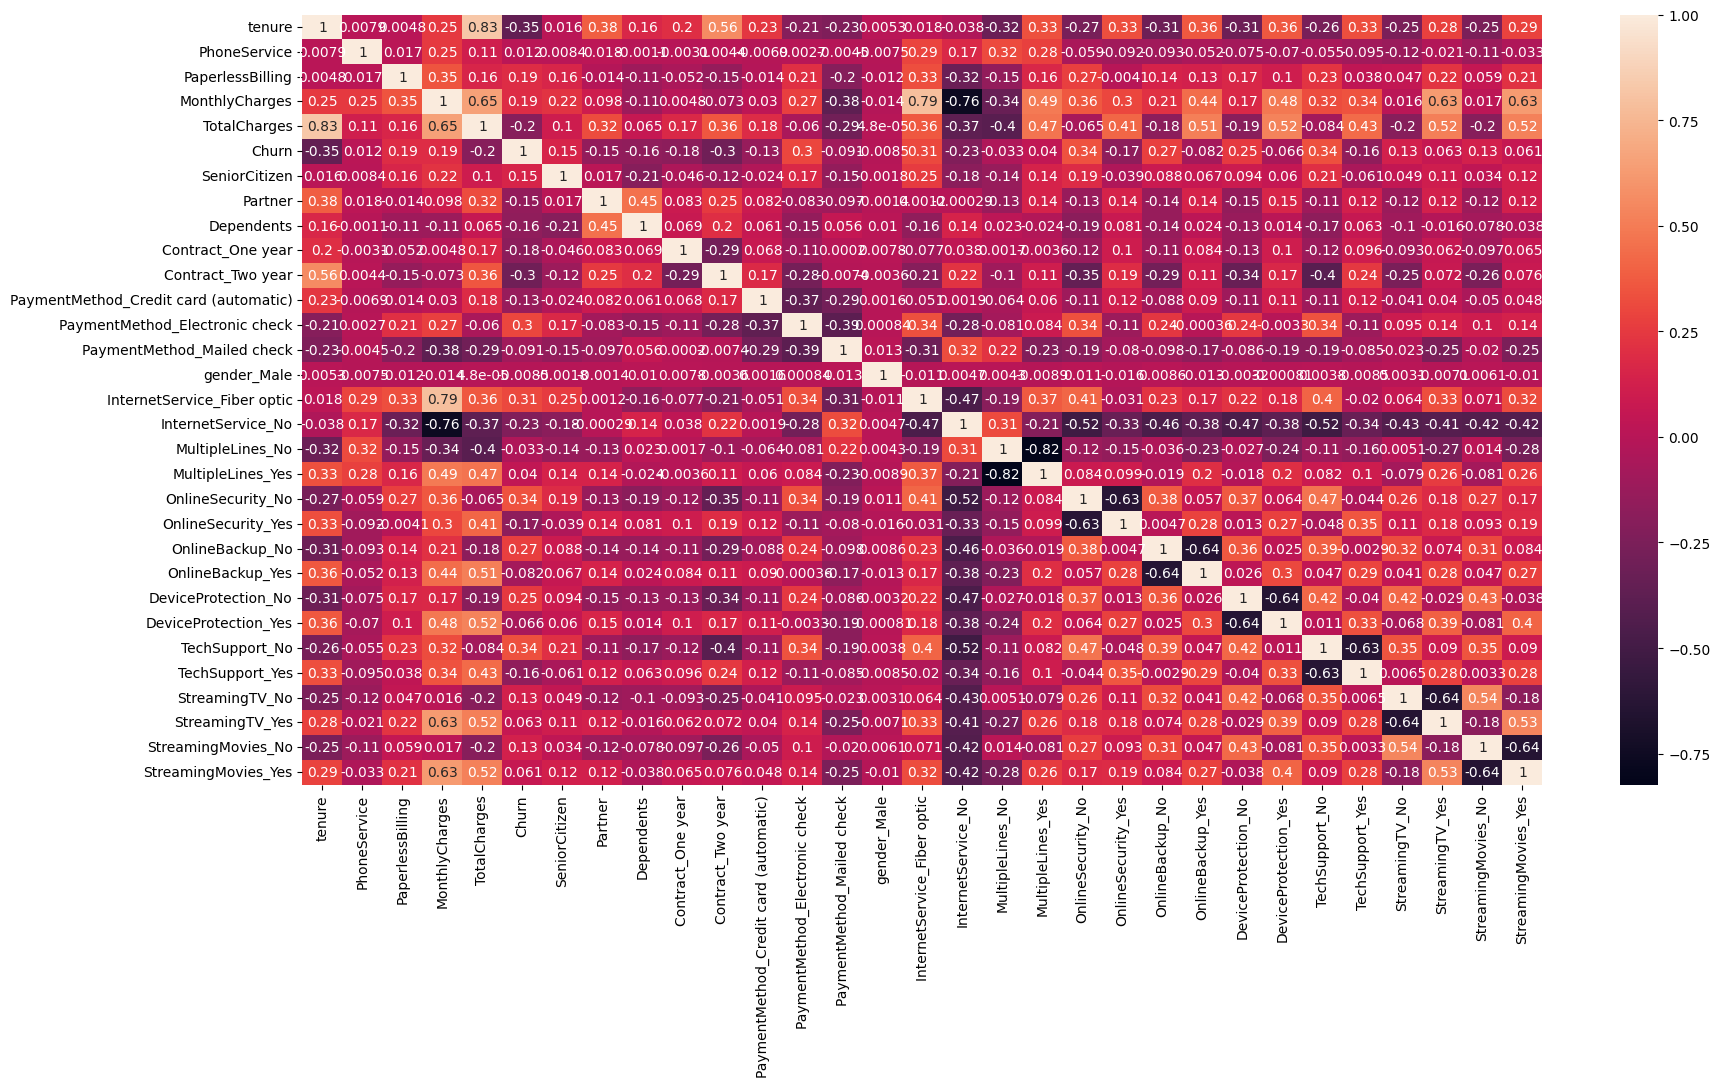

In [78]:
#### Lets see the correlations matrix 
plt.figure(figsize=(20,10))
sns.heatmap(telecom.corr(),annot=True)
plt.show()

### We can see there are lot of correlations variables using this heatmap 
### Also we can observe that - The correlations are mainly held with the newly added dummy variables 
### So lets drop all the dummy variables so that we will get an clear picture on our Analysis 

Its always best to drop the non business oriented data's for EG - we have online streaming Yes or No whic is highly correlated with Internet Service NO  - so now we have planned to drop Streamng yes and no but not Internet Service
the reason why here is - The Word Internet Service is itself very meaningful and understanding by the business - which is business oriented column 
but the correlations columns are not business oriented words - so better to drop Non Business oriented words not Internet Serive NO 

#### So now lets drop all the high correlated dummy variable 

In [79]:
X_test = X_test.drop(['MultipleLines_No','OnlineSecurity_No','OnlineBackup_No','DeviceProtection_No','TechSupport_No',
                       'StreamingTV_No','StreamingMovies_No'], axis = 1)
X_train = X_train.drop(['MultipleLines_No','OnlineSecurity_No','OnlineBackup_No','DeviceProtection_No','TechSupport_No',
                         'StreamingTV_No','StreamingMovies_No'], axis = 1)

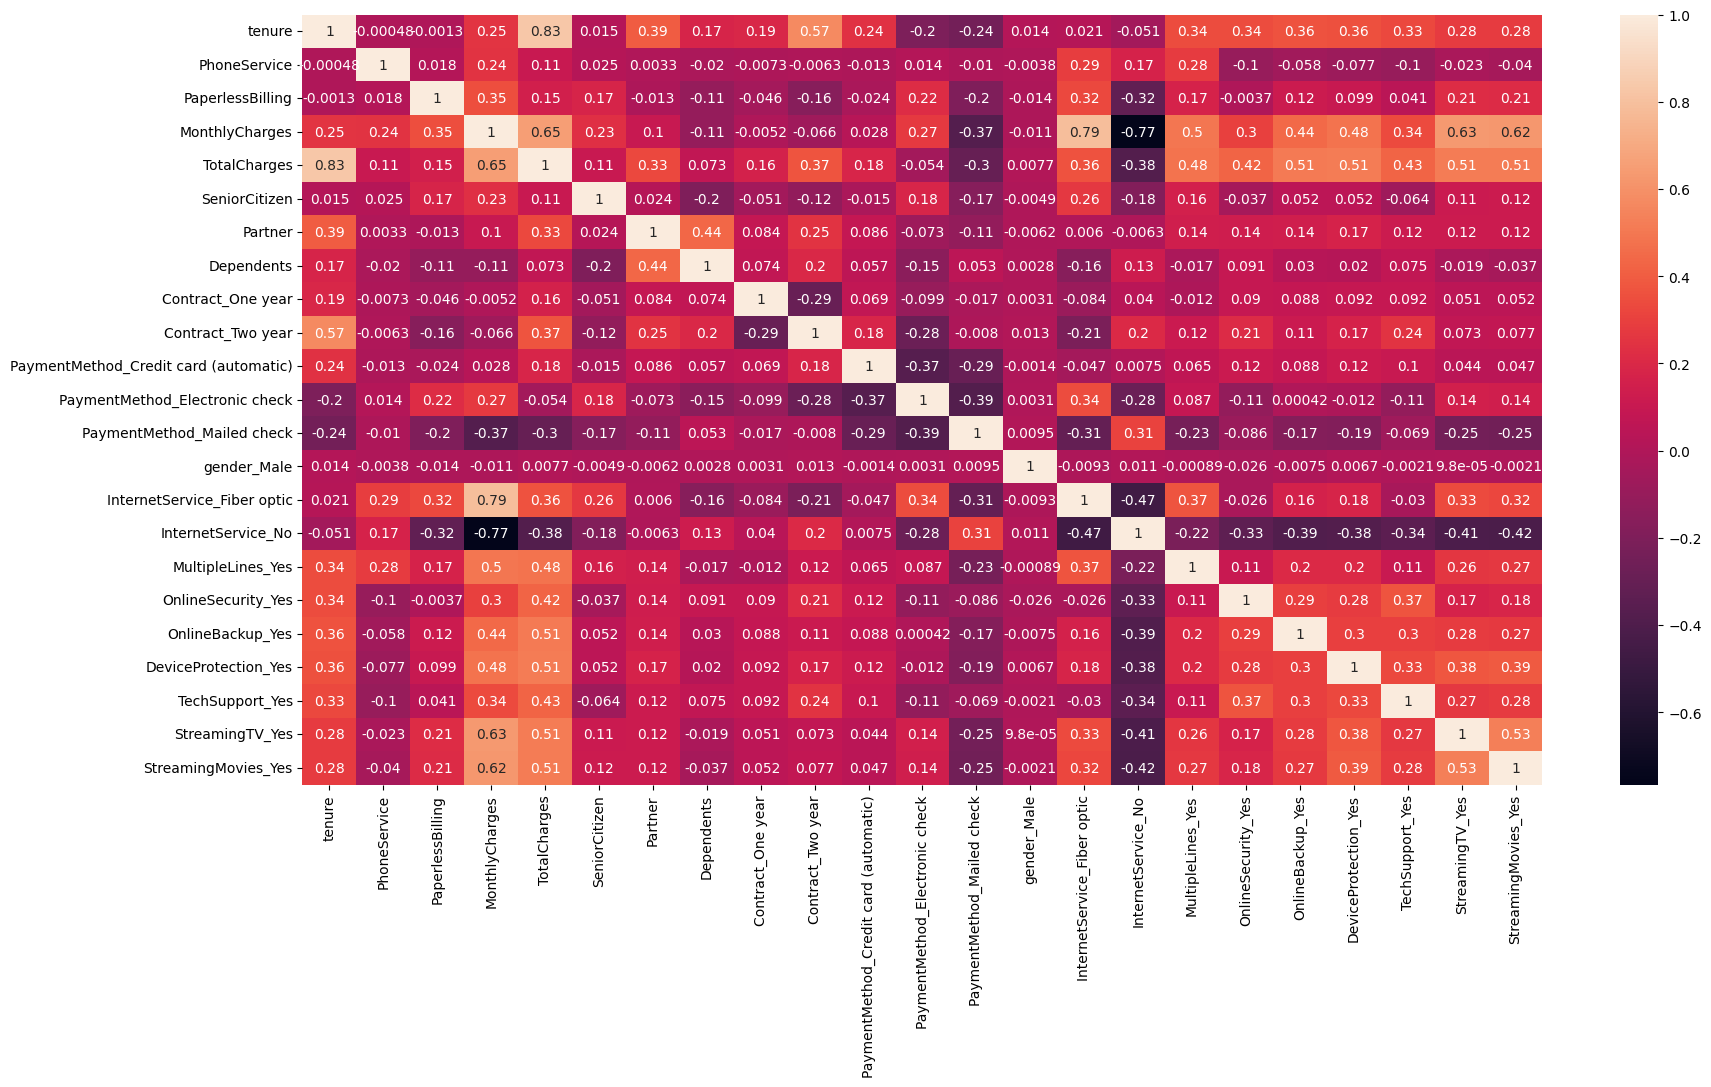

In [80]:
#### Lets have a look on the heatmap again with the fewer variables 
plt.figure(figsize=(20,10))
sns.heatmap(X_train.corr(),annot=True)
plt.show()

After removing the HC variables also we are able to see some of other HC - so its better to drop them but dropping is not an good idea always
lets Start building the model now with all these variables and then we can drop few columns how we did in Multiple linear regression 

#### Lets Start our model building process 
#### Lets Build our model using Stat model as we will get more statastical information 

#### Lets import the requried libraries for Stat model 

In [81]:
import statsmodels.api as sm 

#### as we are already know that when we use this model - we have to add constant as this model by default we have no 
#### constant value with it 
#### So lets add the constant and then see the model building process 

In [82]:
### we are building Stat model with GLM
### On train dataset y_train(Churn dataset) we are adding intercept value on x axis which is X_train (other values except churn) 
### Binomial for whole logestic thing (We are telling to choose Binomial for logestic)
### and you fit that and now finally you want to see the result in the summary

In [83]:
logml = sm.GLM(y_train,(sm.add_constant(X_train )),family = sm.families.Binomial())
logml.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4898
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2004.7
Date:                Mon, 08 Jun 2026   Deviance:                       4009.4
Time:                        21:40:15   Pearson chi2:                 6.07e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2844
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9382      1.546     -2.547      0.011      -6.969      -0.908
tenure                                   -1.5172      0.189     -8.015      0.000      -1.888      -1.146
PhoneService                              0.9507      0.789      1.205      0.228      -0.595       2.497
PaperlessBilling                          0.3254      0.090      3.614      0.000       0.149       0.502
MonthlyCharges                           -2.1806      1.160     -1.880      0.060      -4.454       0.092
TotalCharges                              0.7332      0.198      3.705      0.000       0.345       1.121
SeniorCitizen                             0.3984      0.102      3.924      0.000       0.199       0.597
Partner                                   0.0374      0.094      0.399      0.690      -0.146       0.221
Dependents                               -0.1430      0.107     -1.332      0.183      -0.353       0.067
Contract_One year                        -0.6578      0.129     -5.106      0.000      -0.910      -0.405
Contract_Two year                        -1.2455      0.212     -5.874      0.000      -1.661      -0.830
PaymentMethod_Credit card (automatic)    -0.2577      0.137     -1.883      0.060      -0.526       0.011
PaymentMethod_Electronic check            0.1615      0.113      1.434      0.152      -0.059       0.382
PaymentMethod_Mailed check               -0.2536      0.137     -1.845      0.065      -0.523       0.016
gender_Male                              -0.0346      0.078     -0.442      0.658      -0.188       0.119
InternetService_Fiber optic               2.5124      0.967      2.599      0.009       0.618       4.407
InternetService_No                       -2.7792      0.982     -2.831      0.005      -4.703      -0.855
MultipleLines_Yes                         0.5623      0.214      2.628      0.009       0.143       0.982
OnlineSecurity_Yes                       -0.0245      0.216     -0.113      0.910      -0.448       0.399
OnlineBackup_Yes                          0.1740      0.212      0.822      0.411      -0.241       0.589
DeviceProtection_Yes                      0.3229      0.215      1.501      0.133      -0.099       0.744
TechSupport_Yes                          -0.0305      0.216     -0.141      0.888      -0.455       0.394
StreamingTV_Yes                           0.9598      0.396      2.423      0.015       0.183       1.736
StreamingMovies_Yes                       0.8484      0.396      2.143      0.032       0.072       1.624
=========================================================================================================
"""

# Now lets move to step - Feature selecting using RFE
#####  (Recursive Feature Elimination) Recursive Feature Elimination (RFE) is a feature selection technique used to choose the most important features (or variables) from a dataset.

#### This will not work with State model - this will work only with Sklearn model - so perform this we need to import Sklearn

In [84]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()

In [85]:
from sklearn.feature_selection import RFE


In [86]:
rfe = RFE(logreg, n_features_to_select = 15)
rfe = rfe.fit(X_train, y_train)

In [87]:
telecom.shape

(7032, 31)

##### Out of 31 coulmns we asked to select only 15 columns which is 
##### So RFE selected 

In [88]:
rfe.support_

array([ True, False,  True,  True,  True,  True, False, False,  True,
        True,  True, False,  True, False,  True,  True,  True, False,
       False, False,  True,  True,  True])

In [89]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('tenure', np.True_, np.int64(1)),
 ('PhoneService', np.False_, np.int64(3)),
 ('PaperlessBilling', np.True_, np.int64(1)),
 ('MonthlyCharges', np.True_, np.int64(1)),
 ('TotalCharges', np.True_, np.int64(1)),
 ('SeniorCitizen', np.True_, np.int64(1)),
 ('Partner', np.False_, np.int64(7)),
 ('Dependents', np.False_, np.int64(6)),
 ('Contract_One year', np.True_, np.int64(1)),
 ('Contract_Two year', np.True_, np.int64(1)),
 ('PaymentMethod_Credit card (automatic)', np.True_, np.int64(1)),
 ('PaymentMethod_Electronic check', np.False_, np.int64(4)),
 ('PaymentMethod_Mailed check', np.True_, np.int64(1)),
 ('gender_Male', np.False_, np.int64(8)),
 ('InternetService_Fiber optic', np.True_, np.int64(1)),
 ('InternetService_No', np.True_, np.int64(1)),
 ('MultipleLines_Yes', np.True_, np.int64(1)),
 ('OnlineSecurity_Yes', np.False_, np.int64(2)),
 ('OnlineBackup_Yes', np.False_, np.int64(5)),
 ('DeviceProtection_Yes', np.False_, np.int64(9)),
 ('TechSupport_Yes', np.True_, np.int64(1)),
 ('

In [90]:
#### Lets assign all the RFE selected columns to a new variable col
col = X_train.columns[rfe.support_]

In [91]:
#### These are the models are excluded by the RFE
X_train.columns[~rfe.support_]

Index(['PhoneService', 'Partner', 'Dependents',
       'PaymentMethod_Electronic check', 'gender_Male', 'OnlineSecurity_Yes',
       'OnlineBackup_Yes', 'DeviceProtection_Yes'],
      dtype='str')

### Now lets assess the model only by using the columns which is selected by the RFE 

##### Now again we will use the Stats model to evaluate the model by RFE columns

In [92]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4906
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2011.1
Date:                Mon, 08 Jun 2026   Deviance:                       4022.2
Time:                        21:40:18   Pearson chi2:                 6.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2825
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2462      0.189    -11.879      0.000      -2.617      -1.876
tenure                                   -1.5596      0.187     -8.334      0.000      -1.926      -1.193
PaperlessBilling                          0.3436      0.090      3.832      0.000       0.168       0.519
MonthlyCharges                           -0.9692      0.199     -4.878      0.000      -1.359      -0.580
TotalCharges                              0.7421      0.197      3.764      0.000       0.356       1.128
SeniorCitizen                             0.4296      0.100      4.312      0.000       0.234       0.625
Contract_One year                        -0.6830      0.128     -5.342      0.000      -0.934      -0.432
Contract_Two year                        -1.2931      0.211     -6.138      0.000      -1.706      -0.880
PaymentMethod_Credit card (automatic)    -0.3724      0.113     -3.308      0.001      -0.593      -0.152
PaymentMethod_Mailed check               -0.3723      0.111     -3.345      0.001      -0.591      -0.154
InternetService_Fiber optic               1.5865      0.216      7.342      0.000       1.163       2.010
InternetService_No                       -1.6897      0.216     -7.830      0.000      -2.113      -1.267
MultipleLines_Yes                         0.3779      0.104      3.640      0.000       0.174       0.581
TechSupport_Yes                          -0.2408      0.109     -2.210      0.027      -0.454      -0.027
StreamingTV_Yes                           0.5796      0.114      5.102      0.000       0.357       0.802
StreamingMovies_Yes                       0.4665      0.111      4.197      0.000       0.249       0.684
=========================================================================================================
"""

##### Lets see the predicted values on the training set 

In [93]:
y_train_pred = res.predict(X_train_sm)
y_train_pred [:10]

879     0.192642
5790    0.275624
6498    0.599507
880     0.513571
2784    0.648233
3874    0.414846
5387    0.431184
6623    0.801788
4465    0.228194
5364    0.504575
dtype: float64

In [94]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred [:10]

array([0.19264205, 0.27562384, 0.59950707, 0.51357126, 0.64823272,
       0.41484553, 0.43118361, 0.80178789, 0.22819404, 0.50457542])

### Creating a Data frame with the actual Churn flag and the predicted probability 

In [95]:
y_train_pred_final = pd.DataFrame({'Churn':y_train.values, 'Churn_prob':y_train_pred})
y_train_pred_final['CustID'] = y_train.index
y_train_pred_final.head() 

,Churn,Churn_prob,CustID
0,0,0.192642,879
1,0,0.275624,5790
2,1,0.599507,6498
3,1,0.513571,880
4,1,0.648233,2784


##### Creating new columns 'Predicted' with 1 if churn >0.5 else 0

In [96]:
y_train_pred_final['Predicted'] = y_train_pred_final.Churn_prob.map( lambda x: 1 if x>0.5 else 0)

In [97]:
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted
0,0,0.192642,879,0
1,0,0.275624,5790,0
2,1,0.599507,6498,1
3,1,0.513571,880,1
4,1,0.648233,2784,1


###  Now lets check our model accuracy using a concept called Confusion matrix 

#### The formula for the Condusion matrix is  
 Accuracy = Correctly predicted lables / Total no of labels 

######### To use confusion matrix we have import a library as mentioned below

In [98]:
from sklearn import metrics

In [99]:
#### Confusion matrix 
confusion = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.Predicted )
print(confusion)

[[3275  360]
 [ 574  713]]


In [100]:
# Predicted         Not-churn      churn 
# Actual 
# Not-churn          3275          360 
# Churn              574           713

#### Let's check the overall accuracy 

In [101]:
print(metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.Predicted ))

0.8102397399431126


## Checking VIF

#### Checking for the VIF values of the feature variables 

In [102]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [103]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,MonthlyCharges,14.85
3,TotalCharges,10.42
0,tenure,7.38
9,InternetService_Fiber optic,5.61
10,InternetService_No,5.27
6,Contract_Two year,3.14
13,StreamingTV_Yes,2.79
14,StreamingMovies_Yes,2.79
1,PaperlessBilling,2.76
11,MultipleLines_Yes,2.38


we can see the monthly charges have high VIF , this variable is not helping much in the prediction and making the model complex
lets drop the variable now and see how the model looks like

In [104]:
col = col.drop('MonthlyCharges',1)
col

Index(['tenure', 'PaperlessBilling', 'TotalCharges', 'SeniorCitizen',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes'],
      dtype='str')

### Now lets re-run the model after dropping the variable MonthlyCharges and only with the selected variables

In [105]:
X_train_sm = sm.add_constant(X_train[col])
logm3 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res= logm3.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4907
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2023.1
Date:                Mon, 08 Jun 2026   Deviance:                       4046.2
Time:                        21:40:19   Pearson chi2:                 5.80e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2790
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.5971      0.130    -12.296      0.000      -1.852      -1.343
tenure                                   -1.3286      0.180     -7.401      0.000      -1.681      -0.977
PaperlessBilling                          0.3533      0.089      3.958      0.000       0.178       0.528
TotalCharges                              0.4347      0.186      2.340      0.019       0.071       0.799
SeniorCitizen                             0.4569      0.099      4.601      0.000       0.262       0.652
Contract_One year                        -0.7289      0.127     -5.729      0.000      -0.978      -0.480
Contract_Two year                        -1.3277      0.210     -6.322      0.000      -1.739      -0.916
PaymentMethod_Credit card (automatic)    -0.3870      0.112     -3.442      0.001      -0.607      -0.167
PaymentMethod_Mailed check               -0.3618      0.110     -3.274      0.001      -0.578      -0.145
InternetService_Fiber optic               0.6888      0.109      6.297      0.000       0.474       0.903
InternetService_No                       -0.9555      0.156     -6.120      0.000      -1.262      -0.649
MultipleLines_Yes                         0.1700      0.094      1.814      0.070      -0.014       0.354
TechSupport_Yes                          -0.4371      0.101     -4.307      0.000      -0.636      -0.238
StreamingTV_Yes                           0.2881      0.096      2.996      0.003       0.100       0.477
StreamingMovies_Yes                       0.1944      0.096      2.031      0.042       0.007       0.382
=========================================================================================================
"""

In [106]:
y_train_pred =  res.predict(X_train_sm).values.reshape(-1)
y_train_pred [:10]

array([0.22790197, 0.22864388, 0.67489226, 0.61586836, 0.66226032,
       0.41819928, 0.28813321, 0.7951366 , 0.17433167, 0.51908788])

In [107]:
y_train_pred_final['Churn_prob'] = y_train_pred

##### Creating new columns 'Predicted' with 1 if churn >0.5 else 0

In [108]:
y_train_pred_final['Predicted'] = y_train_pred_final.Churn_prob.map( lambda x: 1 if x>0.5 else 0)
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted
0,0,0.227902,879,0
1,0,0.228644,5790,0
2,1,0.674892,6498,1
3,1,0.615868,880,1
4,1,0.662260,2784,1


#### Lets check the overall accuracy 

In [109]:
print(metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.Predicted ))

0.8057700121901666


so overall accuarcy looks same even after dropping the high VIF variable 
SO now we will check the VIF again to see is there is any possible to drop another high VIF 

In [110]:
## Checking VIF
#### Checking for the VIF values of the available feature variables 

In [111]:
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,TotalCharges,7.46
0,tenure,6.90
5,Contract_Two year,3.07
8,InternetService_Fiber optic,2.96
13,StreamingMovies_Yes,2.62
12,StreamingTV_Yes,2.59
1,PaperlessBilling,2.55
9,InternetService_No,2.44
10,MultipleLines_Yes,2.27
11,TechSupport_Yes,1.95


we can see the Totalcharges have high VIF , this variable is not helping much in the prediction and making the model complex lets drop the variable now and see how the model looks like

In [112]:
col = col.drop('TotalCharges',1)
col

Index(['tenure', 'PaperlessBilling', 'SeniorCitizen', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Mailed check', 'InternetService_Fiber optic',
       'InternetService_No', 'MultipleLines_Yes', 'TechSupport_Yes',
       'StreamingTV_Yes', 'StreamingMovies_Yes'],
      dtype='str')

### Now lets re-run the model after dropping the variable TotalCharges and only with the selected variables

In [113]:
X_train_sm = sm.add_constant(X_train[col])
logm4 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res= logm4.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4908
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2025.9
Date:                Mon, 08 Jun 2026   Deviance:                       4051.9
Time:                        21:40:20   Pearson chi2:                 5.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2782
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.6577      0.127    -13.094      0.000      -1.906      -1.410
tenure                                   -0.9426      0.065    -14.480      0.000      -1.070      -0.815
PaperlessBilling                          0.3455      0.089      3.877      0.000       0.171       0.520
SeniorCitizen                             0.4597      0.100      4.613      0.000       0.264       0.655
Contract_One year                        -0.7218      0.127     -5.702      0.000      -0.970      -0.474
Contract_Two year                        -1.2987      0.208     -6.237      0.000      -1.707      -0.891
PaymentMethod_Credit card (automatic)    -0.3874      0.113     -3.442      0.001      -0.608      -0.167
PaymentMethod_Mailed check               -0.3307      0.110     -3.020      0.003      -0.545      -0.116
InternetService_Fiber optic               0.8052      0.097      8.272      0.000       0.614       0.996
InternetService_No                       -0.9726      0.155     -6.261      0.000      -1.277      -0.668
MultipleLines_Yes                         0.2097      0.092      2.279      0.023       0.029       0.390
TechSupport_Yes                          -0.4046      0.101     -4.019      0.000      -0.602      -0.207
StreamingTV_Yes                           0.3390      0.094      3.619      0.000       0.155       0.523
StreamingMovies_Yes                       0.2428      0.093      2.598      0.009       0.060       0.426
=========================================================================================================
"""

In [114]:
y_train_pred =  res.predict(X_train_sm).values.reshape(-1)
y_train_pred [:10]

array([0.24581699, 0.26536078, 0.66940978, 0.63097033, 0.68291606,
       0.39952622, 0.27582791, 0.79816753, 0.19878625, 0.52911878])

In [115]:
y_train_pred_final['Churn_prob'] = y_train_pred

##### Creating new columns 'Predicted' with 1 if churn >0.5 else 0

In [116]:
y_train_pred_final['Predicted'] = y_train_pred_final.Churn_prob.map( lambda x: 1 if x>0.5 else 0)
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted
0,0,0.245817,879,0
1,0,0.265361,5790,0
2,1,0.669410,6498,1
3,1,0.630970,880,1
4,1,0.682916,2784,1


#### Lets check the overall accuracy again

In [117]:
print(metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.Predicted ))

0.8061763510767981


so overall accuarcy looks same even after dropping the high VIF variable 
SO now we will check the VIF again to see is there is any possible to drop another high VIF 

## Checking VIF
#### Checking for the VIF values of the available feature variables 

In [118]:
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,Contract_Two year,2.98
7,InternetService_Fiber optic,2.67
12,StreamingMovies_Yes,2.54
11,StreamingTV_Yes,2.51
1,PaperlessBilling,2.45
9,MultipleLines_Yes,2.24
0,tenure,2.04
8,InternetService_No,2.03
10,TechSupport_Yes,1.92
3,Contract_One year,1.78


##### So now we have all the variables with low VIF which is lesser than 5 - so in this point we can cosider this is an good model since we have good VIF values 

### Lets see the confusion matrix again 

In [119]:
confusion = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.Predicted )
confusion

array([[3278,  357],
       [ 597,  690]])

In [120]:
### Lets see the overall Accuracy score now with all the low VIF 

In [121]:
print(metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.Predicted ))

0.8061763510767981


### Matrics beyond Simply Accuracy

This brings us to two of the most commonly used metrics to evaluate a classification model:

Sensitivity
Specificity


Actual/Predicted	Not Churn	Churn    
Not Chur        n	326     9	36    6
Chu           rn	5     95	692

Actual/Predicted	Not Churn	       Churn
 Not Churn	        True Negatives	 False Positives
 Churn	            False Negatives	 True Positives 

The first cell contains the actual 'Not Churns' being predicted as 'Not-Churn' and hence, is labelled 'True Negatives' (Negative implying that the 
class is '0', here, Not-Churn.). The second cell contains the actual 'Not Churns' being predicted as 'Churn' and hence, is labelled 'False Positive' 
(because it is predicted as 'Churn' (Positive) but in actuality, it's not a Churn).Similarly, the third cell contains the actual 'Churns' being 
predicted as 'Not Churn' which is why we call it 'False Negative'. And finally, the fourth cell contains the actual 'Churns' being predicted 
as 'Churn' and so, it's labelled as 'True Positives'.
Now, to find out the sensitivity, you first need the number of actual Yeses correctly predicted. 
This number can be found in the last row and the last column of the matrix (which is denoted as true positives). 
This number if 692. Now, you need the total number of actual Yeses. This number will be the sum of the numbers present in the last row, 
i.e. the actual number of churns (this will include the actual churns being wrongly identified as not-churns, and the actual churns being 
correctly identified as churns). Hence, you get (595 + 692) = 1287. 

Now, when you replace these values in the sensitivity formula, you get: 53%
Thus, you can clearly see that although you had a high accuracy (~80.475%), your sensitivity turned out to be quite low (~53.768%)

Now, similarly, specificity is defined as:
As you can now infer, this value will be given by the value True Negatives (3269) divided by the actual number of negatives,
i.e. True Negatives + False Positives (3269 + 366 = 3635). Hence, by replacing these values in the formula, you get specificity as
89.931%

In [122]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [123]:
#### Now lets see the Sensitivity of our logisitic regression model 
###### formula is TP/TP+ FN 
TP/TP+FN
TP/float(TP+FN)

np.float64(0.5361305361305362)

In [124]:
#### Now lets see the Specificity of our logisitic regression model 
###### formula is TN/TN+ FP
TN/float(TN+ FP)

np.float64(0.9017881705639614)

In [125]:
# Calculate false postive rate - predicting churn when customer does not have churned
print(FP/ float(TN+FP))

0.09821182943603851


In [126]:
# positive predictive value 
print (TP / float(TP+FP))

0.6590257879656161


In [127]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8459354838709677


As you can see, the 'False Positive Rate' is basically (1 - Specificity). Check the formula and the values in the code to verify.

The positive predictive value is the number of positives correctly predicted by the total number of positives predicted. 
This is also known as 'Precision' which you'll learn more about soon.

Similarly, the negative predictive value is the number of negatives correctly predicted by the total number of negatives predicted. 
There's no particular term for this as such.



# LETS MOVE THE DATA FRAME INTO THE EXCEL SHEET AND WILL ACCESS IT FROM THERE

In [128]:
y_train_pred_final.to_csv('Churn_probabilities.csv')

we have pulled the dataframe into our excel sheet and saw the True positive Rate and Flase Positive rate 
We created a cut off the we saw wat is TPR and FPR also we found the Churn Rate 
True Positive Rate is nothing about Sensitivity 
False Positive Rate is nothing about Specificity 
Then we saw using the different level of cut off we saw the different TPR and FPR
So using the different level of cutoff we plotted a scatter plot to see how good the model is 
Recall that when the ROC curve is more towards the top left corner of the graph, the model is deemed to be more accurate

### Now lets see how to do the above mentioned activities using Python 
### Plotting the ROC curve 

An ROC curve demonstrates several things:

It shows the tradeoff between sensitivity and specificity (any increase in sensitivity will be accompanied by a decrease in specificity).

The closer the curve follows the left-hand border and then the top border of the ROC space, the more accurate the test.

The closer the curve comes to the 45-degree diagonal of the ROC space, the less accurate the test.

In [129]:
def draw_roc(actual, probs):
    fpr,tpr, thresholds = metrics.roc_curve( actual, probs,
                                            drop_intermediate = False)
    auc_score = metrics.roc_auc_score(actual, probs)
    plt.figure(figsize = (5,5))
    plt.plot(fpr,tpr,label = 'ROC curve(area = %0.2f)' %auc_score )
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Postive Rate or [1 - True Negative Rate]')
    plt.ylabel ('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc='lower right')
    plt.show()

    return None

In [130]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Churn, y_train_pred_final.Churn_prob, drop_intermediate = False )

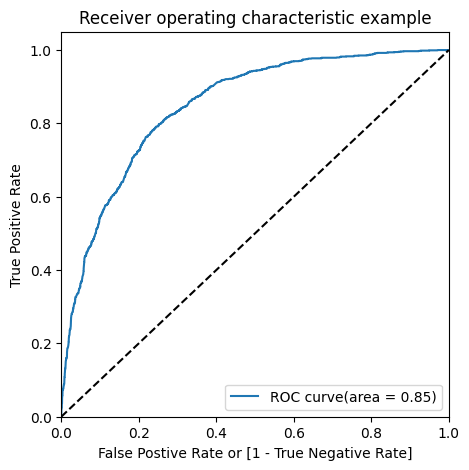

In [131]:
draw_roc(y_train_pred_final.Churn, y_train_pred_final.Churn_prob)

From the above chart you can find the closer the curve follows the left-hand border and then the top border of the ROC space, 
the more accurate the test.

#### Finding the Optimal Threshold is nothing about finding the mid point of the  sensitivity & specificity 
#### Lets see how to do that in python

##### Lets create columns with different probabilities cutoffs 

In [132]:
numbers = [float(x)/10 for x in range (10)]
for i in numbers:
    y_train_pred_final[i] = y_train_pred_final.Churn_prob.map(lambda x: 1 if x>i else 0)
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.245817,879,0,1,1,1,0,0,0,0,0,0,0
1,0,0.265361,5790,0,1,1,1,0,0,0,0,0,0,0
2,1,0.669410,6498,1,1,1,1,1,1,1,1,0,0,0
3,1,0.630970,880,1,1,1,1,1,1,1,1,0,0,0
4,1,0.682916,2784,1,1,1,1,1,1,1,1,0,0,0


In [133]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive 
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.261479  1.000000  0.000000
0.1   0.1  0.614994  0.943279  0.498762
0.2   0.2  0.721861  0.846154  0.677854
0.3   0.3  0.770012  0.776224  0.767813
0.4   0.4  0.790532  0.636364  0.845117
0.5   0.5  0.806176  0.536131  0.901788
0.6   0.6  0.798050  0.380730  0.945805
0.7   0.7  0.776310  0.196581  0.981568
0.8   0.8  0.747867  0.041181  0.998074
0.9   0.9  0.738521  0.000000  1.000000


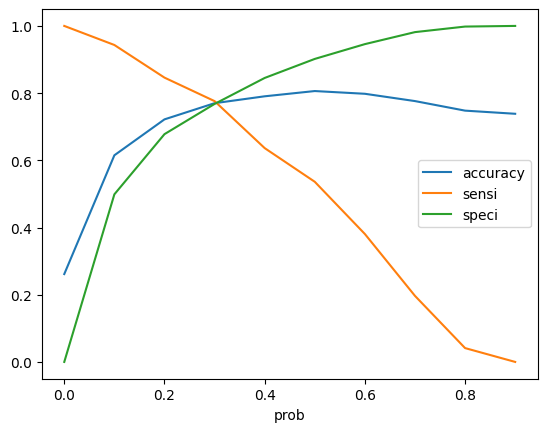

In [134]:
##### Lets plot the accuracy sensitivity and Specificity for different thresholds 
cutoff_df.plot.line(x='prob', y=['accuracy', 'sensi', 'speci'])
plt.show()

In [135]:
y_train_pred_final['predicted'] = y_train_pred_final.Churn_prob.map(lambda x: 1 if x > 0.3 else 0)
y_train_pred_final

,Churn,Churn_prob,CustID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,predicted
0,0,0.245817,879,0,1,1,1,0,0,0,0,0,0,0,0
1,0,0.265361,5790,0,1,1,1,0,0,0,0,0,0,0,0
2,1,0.669410,6498,1,1,1,1,1,1,1,1,0,0,0,1
3,1,0.630970,880,1,1,1,1,1,1,1,1,0,0,0,1
4,1,0.682916,2784,1,1,1,1,1,1,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4917,0,0.024976,79,0,1,0,0,0,0,0,0,0,0,0,0
4918,0,0.095470,3934,0,1,0,0,0,0,0,0,0,0,0,0
4919,0,0.063184,5964,0,1,0,0,0,0,0,0,0,0,0,0
4920,0,0.100672,6947,0,1,1,0,0,0,0,0,0,0,0,0


# Precision and Recall

#### Lets Look at the confusion matrix again 

In [136]:
confusion = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.Predicted )
print(confusion)

[[3278  357]
 [ 597  690]]


Precision 

TP/TP+FP

In [137]:
confusion[1,1]/(confusion[0,1]+confusion[1,1])

np.float64(0.6590257879656161)

Recall

TP/TP+FN

In [138]:
confusion[1,1]/(confusion[1,0]+confusion[1,1])

np.float64(0.5361305361305362)

### Now lets see the above Precision and Recall using SKlearn 

In [139]:
from sklearn.metrics import precision_score , recall_score 

In [140]:
?precision_score

Signature:
precision_score(
    y_true,
    y_pred,
    *,
    labels=None,
    pos_label=1,
    average='binary',
    sample_weight=None,
    zero_division='warn',
)
Docstring:
Compute the precision.

The precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of
true positives and ``fp`` the number of false positives. The precision is
intuitively the ability of the classifier not to label as positive a sample
that is negative.

The best value is 1 and the worst value is 0.

Support beyond :term:`binary` targets is achieved by treating :term:`multiclass`
and :term:`multilabel` data as a collection of binary problems, one for each
label. For the :term:`binary` case, setting `average='binary'` will return
precision for `pos_label`. If `average` is not `'binary'`, `pos_label` is ignored
and precision for both classes are computed, then averaged or both returned (when
`average=None`). Similarly, for :term:`multiclass` and :term:`multilabel` targets,
precision for all `labels`

In [141]:
precision_score(y_train_pred_final.Churn, y_train_pred_final.Predicted )

0.6590257879656161

In [142]:
recall_score(y_train_pred_final.Churn, y_train_pred_final.Predicted )

0.5361305361305362

### Lets Look into the Precision and Recall tradeoff 

In [143]:
from sklearn.metrics import precision_recall_curve  

In [144]:
y_train_pred_final.Churn, y_train_pred_final.Predicted

(0       0
 1       0
 2       1
 3       1
 4       1
        ..
 4917    0
 4918    0
 4919    0
 4920    0
 4921    0
 Name: Churn, Length: 4922, dtype: int64,
 0       0
 1       0
 2       1
 3       1
 4       1
        ..
 4917    0
 4918    0
 4919    0
 4920    0
 4921    0
 Name: Predicted, Length: 4922, dtype: int64)

In [145]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Churn, y_train_pred_final.Churn_prob)

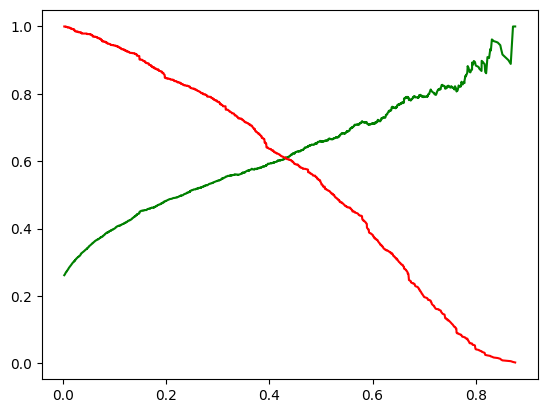

In [146]:
plt.plot(thresholds, p[:-1], 'g-')
plt.plot(thresholds, r[:-1], 'r-')
plt.show()

As you can see, the curve is similar to what you got for sensitivity and specificity. Except now, the curve for precision is quite jumpy towards the end. This is because the denominator of precision, i.e. 
(TP+FP) is not constant as these are the predicted values of 1s. And because the predicted values can swing wildly, you get a very jumpy curve

# Making the prediction on the test set 

### Now go the test set and do the things which we did on the Training set 

#### 1st we need to do the scaling process as we did in our training data set 

In [147]:
X_test[['tenure','MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X_test[['tenure','MonthlyCharges', 'TotalCharges']])

In [148]:
X_test = X_test[col]
X_test.head()

,tenure,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,MultipleLines_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
942,-0.332755,1,0,0,0,1,0,1,0,0,0,0,1
3730,1.006613,1,0,0,0,1,0,1,0,1,0,1,1
1761,1.047200,1,0,0,1,1,0,0,1,1,0,0,0
2283,-1.266254,1,0,0,0,0,1,1,0,0,0,0,0
1872,0.357223,0,0,0,1,0,0,0,1,0,0,0,0


#### 2nd we need to add the constant values 

In [149]:
X_test_sm = sm.add_constant(X_test)

Prediction on the test set

In [150]:
y_test_pred = res.predict(X_test_sm)

In [151]:
y_test_pred[:10]

942     0.416316
3730    0.258890
1761    0.008592
2283    0.588052
1872    0.013846
1970    0.689127
2532    0.283175
1616    0.008924
2485    0.598433
5914    0.143449
dtype: float64

In [152]:
##### Converting y_pred to ta dataframe which is an arary 
y_pred_1 = pd.DataFrame(y_test_pred)

In [153]:
y_pred_1.head()

,0
942,0.416316
3730,0.258890
1761,0.008592
2283,0.588052
1872,0.013846


In [154]:
# Converting y_test to dataframe
y_test_df = pd.DataFrame(y_test)

In [155]:
# Putting CustID to index
y_test_df['CustID'] = y_test_df.index

In [156]:
# Removing index for both dataframes to append them side by side 
y_pred_1.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

In [157]:
# Appending y_test_df and y_pred_1
y_pred_final = pd.concat([y_test_df, y_pred_1],axis=1)

In [158]:
y_pred_final.head()

,Churn,CustID,0
0,0,942,0.416316
1,1,3730,0.258890
2,0,1761,0.008592
3,1,2283,0.588052
4,0,1872,0.013846


In [159]:
# Renaming the column 
y_pred_final= y_pred_final.rename(columns={ 0 : 'Churn_Prob'})

In [160]:
# Rearranging the columns
y_pred_final = y_pred_final.reindex(['CustID','Churn','Churn_Prob'], axis=1)

In [161]:
# Let's see the head of y_pred_final
y_pred_final.head()

,CustID,Churn,Churn_Prob
0,942,0,0.416316
1,3730,1,0.258890
2,1761,0,0.008592
3,2283,1,0.588052
4,1872,0,0.013846


In [162]:
##### Let's take the same optimal threshold which we selected from the train set 

In [163]:
y_pred_final['final_predicted'] = y_pred_final.Churn_Prob.map(lambda x: 1 if x > 0.3 else 0)

In [164]:
y_pred_final.head()

,CustID,Churn,Churn_Prob,final_predicted
0,942,0,0.416316,1
1,3730,1,0.258890,0
2,1761,0,0.008592,0
3,2283,1,0.588052,1
4,1872,0,0.013846,0


In [165]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_pred_final.Churn, y_pred_final.final_predicted)

0.7436018957345971

In [166]:
confusion2 = metrics.confusion_matrix(y_pred_final.Churn, y_pred_final.final_predicted )
confusion2

array([[1151,  377],
       [ 164,  418]])

In [167]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [168]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.718213058419244)

In [169]:
# Let us calculate specificity
TN / float(TN+FP)

np.float64(0.7532722513089005)

## Notes - 

Logistic Regression
Based on your understanding till now, what are the two main differences between logistic regression and linear regression?

The two main important differences between logistic and linear regression are: 1. Dependent/response variable in linear regression is continuous 
whereas, in logistic regression, it is the discrete type. 2. Cost function in linear regression minimise the error term Sum(Actual(Y)-Predicted(Y))^2 
but logistic regression uses maximum likelihood method for maximising probabilities.

# Nuances of Logistic Regression - Variable Transformation-I

Now, the next steps, as you may recall from the last session, are dummy variable creation, standardising scales of continuous variables, etc. These processes are generally referred to as variable transformation. Can other types of variable transformations be performed before building a logistic regression model?

From earlier sessions, you already know that categorical variables have to be transformed into dummies. Also, you were told that numeric variables have to be standardised, so that they all have the same scale. However, you could also convert numeric variables into dummy variables, using the techniques mentioned by Hindol in the video above.

There are some pros and cons of transforming variables to dummies. Creating dummies for categorical variables is very straightforward. You can directly create n-1 new variables from an existing categorical variable if it has n levels. But for continuous variables, you would be required to do some kind of EDA analysis for binning the variables.

The major advantage offered by dummies especially for continuous variables is that they make the model stable. In other words, small variations in the variables would not have a very big impact on a model that was made using dummies, but they would still have a sizeable impact on a model built using continuous variables as is.

On the other side, there are some major disadvantages that exist. E.g. if you change the continuous variable to dummies, all the data will be compressed into very few categories and that might result in data clumping.

# Nuances of Logistic Regression - Variable Transformation-II

#### So, creating dummy variables is one way of transforming variables. Let’s now move on to another technique commonly used for transforming variables — Weight of evidence (WOE) analysis.

So, to summarise, you learnt three important things in this lecture:

Calculating woe values for fine binning and coarse binning

The importance of woe for fine binning and coarse binning

The usage of woe transformation

So, basically, the pros and cons of a WOE transformation are similar to dummy variables.

Pros: The model becomes more stable because small changes in the continuous variables will not impact the input so much.
Cons: You may end up doing some score clumping.
 

This is because when you are using WOE values in your model, you are doing something similar to creating dummy variables — you are replacing a range of values with an indicative variable. It is just that, instead of replacing it with a simple 1 or 0, which was not thought out at all, you are replacing it with a well thought out WOE value. Hence, the chances of undesired score clumping will be a lot less here.

 

Let's now move on to IV (Information Value), which is a very important concept.

So, information value can be calculated using the following expression:

Mainly, it helps you understand how the binning of variables should be done. The binning should be done such that the WOE trend across bins is monotonic — either increasing all the time or decreasing all the time. But one more thing that needs to be taken care of is that IV (information value) should be high.

# Nuances of Logistic Regression - Variable Transformation-III


This is how you can work on continuous variables.

 

In the next lecture, you will learn about some advanced transformation techniques such as spline transformation, interaction variables, mathematical transformation and principal component transformation. These transformations are hardly used in the model exercise. However, let’s see what the benefits and importance of these transformations are in the next lecture.

 

Comprehension  2: Missing Value -WOE


You saw that NA values can be treated with WOE values. However, you can replace the NA bucket with a bucket which shows similar woe values.

# Summary of Logistic Regression Nuances 

1. Types of Logistic Regression 
2. Logistic Regression Nuances 


    a . Sample Selection 
    b. Segmentation
    c. Variable Transformation

   
        Under Variable Transformation 

        
            > Dummary Variable Transformation 
            > Weight of Evidence WOE Transformation 
            > Continuous Variable Transformtion 
            > Interaction Variables 
            > Splines 
            > Mathematical Transformations
            > Principal component transformation 


# Commonly Faced Challenges in Implementation of Logistic Regression


Let's look back at the credit card example from earlier sessions.

 

Let's look at 2 cases, where the variable's value is missing (equal to NA):

Utilisation is missing: As mentioned earlier, if this variable is missing for a particular customer, that could very well be because the bank did not find that customer worthy enough for a credit card. Hence, these missing values are not missing at random, and it would be unfair to just replace them with the mean or the median. As mentioned earlier, it would be wiser to perform a WOE analysis and then replace these values.
Age is missing: Consider why the variable age is missing for some customers. Here, it may actually make more sense to just replace the missing value with the mean or the median, instead of wasting time on WOE analysis. This is because it is very likely that the variable age is just missing because of a system error or a manual error, and there is no clear pattern behind the missing values.

# Model Validation and Importance of Stability


Basically, there are 3 iterations in which evaluation is done. In the first iteration, 1/3rd of the data is selected as training data and the remaining 2/3rd of it is selected as testing data. In the next iteration, a different 1/3rd of the data is selected as the training data set and then the model is built and evaluated. Similarly, the third iteration is completed.

 

Such an approach is necessary if the data you have for model building is very small, i.e. has very few data points.

 

If these three methods of validation are still unclear to you, you need not worry as of now. They will be covered at length in the module on Model Selection.

Obviously, a good model will be stable. A model is considered stable if it has:

Performance Stability: Results of in-sample validation approximately match those of out-of-time validation
Variable Stability: The sample used for model building hasn't changed too much and has the same general characteristics

# Tracking of Model Performance Over Time


So, the first time, when the model's Gini dropped to 0.72, you avoided building a new model. Basically, you just recalibrated, i.e. updated the coefficients of the variables. That resulted in a slight increase of Gini. However, the next time Gini dropped to a low value, i.e. 0.71, we just rebuilt the model, i.e. got new sample data, performed data prep, etc. and built the entire model.

# Summary

1 Types of Logistic Regression 

2 Logistic Regression Nuances

3 Model Evaluation (Performance Measures)

    Discriminatory  Power 
        KS Statistics
        Gini
        Rank Ordering
        Sensitivity 
        Specificity 
    Accuracy 
        Sensitivity 
        Specificity 
        Compare Actual vs Predicted Log odds
    Stability 
        Performance stability 
        Variable Stability 
            Variable Distribution Stability 
            Population Stability index 
    Model Validation 
        In-Sample Validation 
        Out of time Validation 
        K-Cros  Validation
        
4 Model Tracking 

5 Model Reclibration 


# End of Logistic Regression 